# 03a Multi-Model Autoencoder Training

Este notebook entrena multiples configuraciones de autoencoder para identificar
la dimension latente optima y calcular indices de resiliencia.

## Objetivo

1. Entrenar autoencoders con diferentes latent_dim (7D, 12D, 15D)
2. Evaluar dimensionalidad intrinseca del espacio latente
3. Calcular indices de resiliencia climatica
4. Comparar configuraciones y seleccionar modelo optimo

## Flujo de trabajo

```
02_preprocess → 03a_multimodel → 05_resilience
                     (este notebook)
```

## Variables disponibles desde notebook 02

- X_train, X_val, X_test: Datos normalizados por escenario
- X_original_train, X_original_val, X_original_test: Datos originales (sin normalizar)
- feature_names: Lista de 293 nombres de variables
- scenario_labels: Etiquetas de escenarios SSP (245/370/585)
- scalers: Diccionario de normalizadores por variable
- grid_shape: (lat, lon) dimensiones espaciales
- lat_coords, lon_coords: Coordenadas geograficas

---
## 1. Configuracion e Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
import time
from datetime import datetime

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
tf.random.set_seed(42)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU disponible: {gpus[0].name}")
else:
    print("Ejecutando en CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

GPU disponible: /physical_device:GPU:0
TensorFlow version: 2.19.0
NumPy version: 1.26.4


In [10]:
# Configuracion de rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'  # Datos del notebook 02
MODEL_DIR = BASE_DIR / 'data' / 'autoencoder_trained'
OUT_DIR = BASE_DIR / 'data' / 'autoencoder_results'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_training'

# Crear directorios
MODEL_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Parametros de entrenamiento
CONFIG = {
    'batch_size': 32,
    'epochs': 500,
    'learning_rate': 1e-3,
    'patience': 50,
    'min_delta': 1e-5,
    'seed': 42,
    'mode': 'test',  # Debe coincidir con notebook 02
    'scenarios': ['ssp245', 'ssp370', 'ssp585']
}

# Configuracion de experimentos
EXPERIMENTS = {
    'Model_A': {
        'latent_dim': 7,
        'description': 'Baseline - 7D latente',
        'filter_pattern': None  # Todas las variables
    },
    'Model_B': {
        'latent_dim': 12,
        'description': 'Dimension optima sugerida - 12D',
        'filter_pattern': None
    },
    'Model_C': {
        'latent_dim': 15,
        'description': 'Dimension maxima exploratoria - 15D',
        'filter_pattern': None
    }
}

# Control de ejecucion
RUN_TRAINING = True  # Cambiar a True para entrenar modelos

print("="*80)
print("CONFIGURACION MULTI-MODEL AUTOENCODER")
print("="*80)
print(f"\nDirectorios:")
print(f"  Datos tensores: {TENSORS_DIR}")
print(f"  Modelos guardados: {MODEL_DIR}")
print(f"  Resultados: {OUT_DIR}")
print(f"  Plots: {PLOTS_DIR}")
print(f"\nParametros de entrenamiento:")
for key, val in CONFIG.items():
    print(f"  {key}: {val}")
print(f"\nExperimentos configurados: {len(EXPERIMENTS)}")
for exp_name, exp_config in EXPERIMENTS.items():
    print(f"  - {exp_name}: {exp_config['description']} (latent_dim={exp_config['latent_dim']})")
print(f"\nEjecutar entrenamiento: {RUN_TRAINING}")
print("="*80)


CONFIGURACION MULTI-MODEL AUTOENCODER

Directorios:
  Datos tensores: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors
  Modelos guardados: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained
  Resultados: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results
  Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_training

Parametros de entrenamiento:
  batch_size: 32
  epochs: 500
  learning_rate: 0.001
  patience: 50
  min_delta: 1e-05
  seed: 42
  mode: test
  scenarios: ['ssp245', 'ssp370', 'ssp585']

Experimentos configurados: 3
  - Model_A: Baseline - 7D latente (latent_dim=7)
  - Model_B: Dimension optima sugerida - 12D (latent_dim=12)
  - Model_C: Dimension maxima exploratoria - 15D (latent_dim=15)

Ejecutar entrenamiento: True


---
## 2. Cargar Datos Preprocesados

Cargar datos desde notebook 02_preprocess_for_autoencoder.ipynb

In [12]:
print("="*80)
print("CARGANDO DATOS PREPROCESADOS")
print("="*80)

MODE = CONFIG['mode']
SCENARIOS = CONFIG['scenarios']

# Cargar feature names
features_file = TENSORS_DIR / f'feature_names_{MODE}.csv'
feature_names = pd.read_csv(features_file)['feature_name'].tolist()
print(f"\nFeatures cargadas: {len(feature_names)}")
print(f"  Primeras 5: {feature_names[:5]}")

# Cargar metadata
metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

# Extraer info espacial (estructura actualizada del notebook 02)
spatial_info = metadata['spatial_info']
grid_shape = spatial_info['grid_shape']
lat_coords = spatial_info['lat']
lon_coords = spatial_info['lon']

print(f"\nMetadata:")
print(f"  Grid shape: {grid_shape}")
print(f"  Lat range: [{lat_coords.min():.2f}, {lat_coords.max():.2f}]")
print(f"  Lon range: [{lon_coords.min():.2f}, {lon_coords.max():.2f}]")

# Cargar datos normalizados por escenario
scenario_data = {}

for scenario in SCENARIOS:
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    scenario_data[scenario] = {
        'X_train': data['X_train'],
        'X_val': data['X_val'],
        'X_test': data['X_test'],
        'train_idx': data['train_idx'],
        'val_idx': data['val_idx'],
        'test_idx': data['test_idx']
    }
    
    print(f"\n{scenario.upper()}:")
    print(f"  Train: {scenario_data[scenario]['X_train'].shape}")
    print(f"  Val:   {scenario_data[scenario]['X_val'].shape}")
    print(f"  Test:  {scenario_data[scenario]['X_test'].shape}")

# Combinar todos los escenarios
X_train = np.vstack([scenario_data[s]['X_train'] for s in SCENARIOS])
X_val = np.vstack([scenario_data[s]['X_val'] for s in SCENARIOS])
X_test = np.vstack([scenario_data[s]['X_test'] for s in SCENARIOS])

# Crear etiquetas de escenario
scenario_labels_train = np.concatenate([
    np.full(scenario_data[s]['X_train'].shape[0], i) 
    for i, s in enumerate(SCENARIOS)
])
scenario_labels_val = np.concatenate([
    np.full(scenario_data[s]['X_val'].shape[0], i) 
    for i, s in enumerate(SCENARIOS)
])
scenario_labels_test = np.concatenate([
    np.full(scenario_data[s]['X_test'].shape[0], i) 
    for i, s in enumerate(SCENARIOS)
])

print(f"\n{'='*80}")
print("DATOS COMBINADOS (MULTI-ESCENARIO)")
print(f"{'='*80}")
print(f"Train: {X_train.shape} (escenarios: {np.unique(scenario_labels_train)})")
print(f"Val:   {X_val.shape} (escenarios: {np.unique(scenario_labels_val)})")
print(f"Test:  {X_test.shape} (escenarios: {np.unique(scenario_labels_test)})")
print(f"\nTotal features: {X_train.shape[1]}")
print(f"Total samples: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print("="*80)


CARGANDO DATOS PREPROCESADOS

Features cargadas: 293
  Primeras 5: ['calliope_h2_prod_ton', 'calliope_lcoh_usd_kg', 'calliope_cap_electrolyzer_mw', 'calliope_cf_mean', 'topo_slope']

Metadata:
  Grid shape: (24, 42)
  Lat range: [-33.33, -32.17]
  Lon range: [-71.97, -69.93]

SSP245:
  Train: (462, 293)
  Val:   (99, 293)
  Test:  (100, 293)

SSP370:
  Train: (462, 293)
  Val:   (99, 293)
  Test:  (100, 293)

SSP585:
  Train: (462, 293)
  Val:   (99, 293)
  Test:  (100, 293)

DATOS COMBINADOS (MULTI-ESCENARIO)
Train: (1386, 293) (escenarios: [0 1 2])
Val:   (297, 293) (escenarios: [0 1 2])
Test:  (300, 293) (escenarios: [0 1 2])

Total features: 293
Total samples: 1983


---
## 3. Funciones de Construccion de Modelos

In [13]:
def build_autoencoder(input_dim, latent_dim, name='autoencoder'):
    """
    Construir autoencoder con arquitectura escalable.
    
    Args:
        input_dim: Dimension de entrada
        latent_dim: Dimension del espacio latente
        name: Nombre del modelo
    
    Returns:
        autoencoder: Modelo completo
        encoder: Modelo encoder
        decoder: Modelo decoder
    """
    # Calcular capas intermedias
    if input_dim > 256:
        layer1, layer2, layer3 = 256, 128, 64
    elif input_dim > 128:
        layer1, layer2, layer3 = 128, 64, 32
    else:
        layer1 = max(64, input_dim // 2)
        layer2 = max(32, input_dim // 4)
        layer3 = max(16, latent_dim * 2)
    
    # Encoder
    input_layer = Input(shape=(input_dim,), name='input')
    x = Dense(layer1, name='enc_dense1')(input_layer)
    x = LeakyReLU(name='enc_relu1')(x)
    x = Dense(layer2, name='enc_dense2')(x)
    x = LeakyReLU(name='enc_relu2')(x)
    x = Dense(layer3, name='enc_dense3')(x)
    x = LeakyReLU(name='enc_relu3')(x)
    latent = Dense(latent_dim, activation='linear', name='latent')(x)
    
    # Decoder
    x = Dense(layer3, name='dec_dense1')(latent)
    x = LeakyReLU(name='dec_relu1')(x)
    x = Dense(layer2, name='dec_dense2')(x)
    x = LeakyReLU(name='dec_relu2')(x)
    x = Dense(layer1, name='dec_dense3')(x)
    x = LeakyReLU(name='dec_relu3')(x)
    output = Dense(input_dim, activation='linear', name='output')(x)
    
    # Modelos
    autoencoder = Model(input_layer, output, name=name)
    encoder = Model(input_layer, latent, name=f'{name}_encoder')
    
    # Decoder independiente
    latent_input = Input(shape=(latent_dim,), name='latent_input')
    x = autoencoder.get_layer('dec_dense1')(latent_input)
    x = autoencoder.get_layer('dec_relu1')(x)
    x = autoencoder.get_layer('dec_dense2')(x)
    x = autoencoder.get_layer('dec_relu2')(x)
    x = autoencoder.get_layer('dec_dense3')(x)
    x = autoencoder.get_layer('dec_relu3')(x)
    x = autoencoder.get_layer('output')(x)
    decoder = Model(latent_input, x, name=f'{name}_decoder')
    
    print(f"\nArquitectura {name}:")
    print(f"  Encoder: {input_dim} -> {layer1} -> {layer2} -> {layer3} -> {latent_dim}")
    print(f"  Decoder: {latent_dim} -> {layer3} -> {layer2} -> {layer1} -> {input_dim}")
    print(f"  Parametros totales: {autoencoder.count_params():,}")
    
    return autoencoder, encoder, decoder


def calculate_intrinsic_dimensionality(embeddings, k=20):
    """
    Estimar dimensionalidad intrinseca usando MLE.
    
    Args:
        embeddings: Array de embeddings (n_samples, n_dims)
        k: Numero de vecinos cercanos
    
    Returns:
        d_intrinsic: Estimacion de dimensionalidad
    """
    from sklearn.neighbors import NearestNeighbors
    
    n_samples = embeddings.shape[0]
    k = min(k, n_samples - 1)
    
    # Calcular distancias a k vecinos
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(embeddings)
    distances, _ = nbrs.kneighbors(embeddings)
    distances = distances[:, 1:]  # Excluir distancia a si mismo
    
    # MLE estimator
    r_k = distances[:, -1]  # Distancia al k-esimo vecino
    r_k = np.maximum(r_k, 1e-10)  # Evitar log(0)
    
    sum_log_ratios = 0
    for i in range(k-1):
        r_i = distances[:, i]
        r_i = np.maximum(r_i, 1e-10)
        log_ratio = np.log(r_k / r_i)
        sum_log_ratios += np.mean(log_ratio)
    
    d_intrinsic = (k - 1) / sum_log_ratios if sum_log_ratios > 0 else 0
    
    return d_intrinsic


print("Funciones de construccion y analisis definidas")

Funciones de construccion y analisis definidas


---
## 4. Entrenamiento Multi-Modelo

In [14]:
print("="*80)
print("ENTRENAMIENTO MULTI-MODELO")
print("="*80)

if not RUN_TRAINING:
    print("\nRUN_TRAINING = False")
    print("  Cambia RUN_TRAINING = True en la celda de configuracion para entrenar")
    print("  Los modelos NO seran entrenados")
    print("="*80)
else:
    input_dim = X_train.shape[1]
    experiment_results = {}
    
    for exp_name, exp_config in EXPERIMENTS.items():
        print(f"\n{'='*80}")
        print(f"ENTRENANDO: {exp_name}")
        print(f"  {exp_config['description']}")
        print(f"{'='*80}")
        
        try:
            start_time = time.time()
            latent_dim = exp_config['latent_dim']
            
            # Construir modelo
            autoencoder, encoder, decoder = build_autoencoder(
                input_dim, latent_dim, name=exp_name
            )
            
            # Compilar
            autoencoder.compile(
                optimizer=Adam(learning_rate=CONFIG['learning_rate']),
                loss='mse',
                metrics=['mae']
            )
            
            # Callbacks
            checkpoint_path = MODEL_DIR / f'{exp_name}_best_{MODE}.keras'
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=CONFIG['patience'],
                    min_delta=CONFIG['min_delta'],
                    restore_best_weights=True,
                    verbose=1
                ),
                ModelCheckpoint(
                    filepath=checkpoint_path,
                    monitor='val_loss',
                    save_best_only=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=CONFIG['patience'] // 2,
                    min_lr=1e-7,
                    verbose=1
                )
            ]
            
            # Entrenar
            print(f"\nEntrenando {exp_name}...")
            history = autoencoder.fit(
                X_train, X_train,
                validation_data=(X_val, X_val),
                epochs=CONFIG['epochs'],
                batch_size=CONFIG['batch_size'],
                callbacks=callbacks,
                verbose=0
            )
            
            # Evaluar
            test_metrics = autoencoder.evaluate(X_test, X_test, verbose=0)
            test_mse = float(test_metrics[0])
            test_mae = float(test_metrics[1])
            
            # Generar embeddings
            embeddings_train = encoder.predict(X_train, verbose=0)
            embeddings_val = encoder.predict(X_val, verbose=0)
            embeddings_test = encoder.predict(X_test, verbose=0)
            
            # Calcular dimensionalidad intrinseca
            d_intrinsic_train = calculate_intrinsic_dimensionality(embeddings_train)
            d_intrinsic_test = calculate_intrinsic_dimensionality(embeddings_test)
            
            training_time = time.time() - start_time
            
            print(f"\nResultados {exp_name}:")
            print(f"  Tiempo: {training_time/60:.1f} min")
            print(f"  Epochs: {len(history.history['loss'])}")
            print(f"  Test MSE: {test_mse:.6f}")
            print(f"  Test MAE: {test_mae:.6f}")
            print(f"  Dimensionalidad intrinseca (train): {d_intrinsic_train:.2f}")
            print(f"  Dimensionalidad intrinseca (test): {d_intrinsic_test:.2f}")
            
            # Guardar resultados
            experiment_results[exp_name] = {
                'latent_dim': int(latent_dim),
                'n_features': int(input_dim),
                'n_params': int(autoencoder.count_params()),
                'test_mse': float(test_mse),
                'test_mae': float(test_mae),
                'd_intrinsic_train': float(d_intrinsic_train),
                'd_intrinsic_test': float(d_intrinsic_test),
                'training_time_min': float(training_time / 60),
                'epochs_trained': int(len(history.history['loss'])),
                'model_path': str(checkpoint_path),
                'status': 'completed'
            }
            
            # Guardar embeddings
            embeddings_file = OUT_DIR / f'{exp_name}_embeddings_{MODE}.pkl'
            with open(embeddings_file, 'wb') as f:
                pickle.dump({
                    'train': embeddings_train,
                    'val': embeddings_val,
                    'test': embeddings_test,
                    'scenario_labels_train': scenario_labels_train,
                    'scenario_labels_val': scenario_labels_val,
                    'scenario_labels_test': scenario_labels_test,
                    'latent_dim': latent_dim
                }, f)
            
            # Guardar historia
            history_file = OUT_DIR / f'{exp_name}_history_{MODE}.pkl'
            with open(history_file, 'wb') as f:
                pickle.dump(history.history, f)
            
            print(f"  Embeddings guardados: {embeddings_file.name}")
            print(f"  Historia guardada: {history_file.name}")
            
        except Exception as e:
            print(f"\nERROR en {exp_name}: {str(e)}")
            experiment_results[exp_name] = {
                'status': 'failed',
                'error': str(e)
            }
    
    # Guardar resultados comparativos
    results_file = OUT_DIR / f'multi_model_comparison_{MODE}.json'
    with open(results_file, 'w') as f:
        json.dump(experiment_results, f, indent=2)
    
    print(f"\n{'='*80}")
    print("RESUMEN DE EXPERIMENTOS")
    print(f"{'='*80}")
    print(f"\n{'Modelo':<12} {'Latent':<8} {'MSE':<12} {'MAE':<12} {'d_int_test':<12} {'Estado':<12}")
    print("-" * 80)
    for exp_name, results in experiment_results.items():
        if results['status'] == 'completed':
            print(f"{exp_name:<12} {results['latent_dim']:<8} {results['test_mse']:<12.6f} "
                  f"{results['test_mae']:<12.6f} {results['d_intrinsic_test']:<12.2f} OK")
        else:
            print(f"{exp_name:<12} {'N/A':<8} {'N/A':<12} {'N/A':<12} {'N/A':<12} FAILED")
    
    print(f"\n{'='*80}")
    print(f"Resultados guardados: {results_file.name}")
    print(f"{'='*80}")

ENTRENAMIENTO MULTI-MODELO

ENTRENANDO: Model_A
  Baseline - 7D latente


I0000 00:00:1762140923.215351  444569 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4958 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9



Arquitectura Model_A:
  Encoder: 293 -> 256 -> 128 -> 64 -> 7
  Decoder: 7 -> 64 -> 128 -> 256 -> 293
  Parametros totales: 234,028

Entrenando Model_A...


I0000 00:00:1762140924.383660  445300 service.cc:152] XLA service 0x7f5f9c010b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762140924.383674  445300 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2025-11-03 00:35:24.403197: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1762140924.528226  445300 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-11-03 00:35:25.118805: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_547', 660 bytes spill stores, 664 bytes spill loads

2025-11-03 00:35:25.118805: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5


Epoch 168: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 209: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 209: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 268: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 268: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 349: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 349: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 497: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 497: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Restoring model weights from the end of the best epoch: 499.
Restoring model weights from the end of the best epoch: 499.

Resultados Model_A:
  Tiempo: 1.0 min
  Epochs: 500
  Test MSE: 0.027640
  Test MAE: 0.091550
  Dimensionalidad intrinseca (train): 2.17
  Dimensionalidad intrinseca (t

---
## 5. Cargar Resultados (si ya fueron entrenados)

In [15]:
# Cargar resultados de experimentos previos
results_file = OUT_DIR / f'multi_model_comparison_{MODE}.json'

if results_file.exists():
    with open(results_file, 'r') as f:
        experiment_results = json.load(f)
    
    print("="*80)
    print("RESULTADOS CARGADOS")
    print("="*80)
    print(f"\nArchivo: {results_file.name}")
    print(f"Experimentos encontrados: {len(experiment_results)}\n")
    
    # Tabla comparativa
    df_results = pd.DataFrame(experiment_results).T
    print(df_results[['latent_dim', 'test_mse', 'test_mae', 'd_intrinsic_test', 'status']])
    print("="*80)
else:
    print(f"\nNo se encontraron resultados previos en: {results_file}")
    print("  Ejecuta el entrenamiento con RUN_TRAINING = True")

RESULTADOS CARGADOS

Archivo: multi_model_comparison_test.json
Experimentos encontrados: 3

        latent_dim  test_mse  test_mae d_intrinsic_test     status
Model_A          7   0.02764   0.09155         2.151283  completed
Model_B         12  0.021742  0.084575         2.343328  completed
Model_C         15  0.020685  0.083297         2.325098  completed


---
## 6. Analisis Comparativo de Modelos


Grafico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_training/multi_model_comparison_test.png


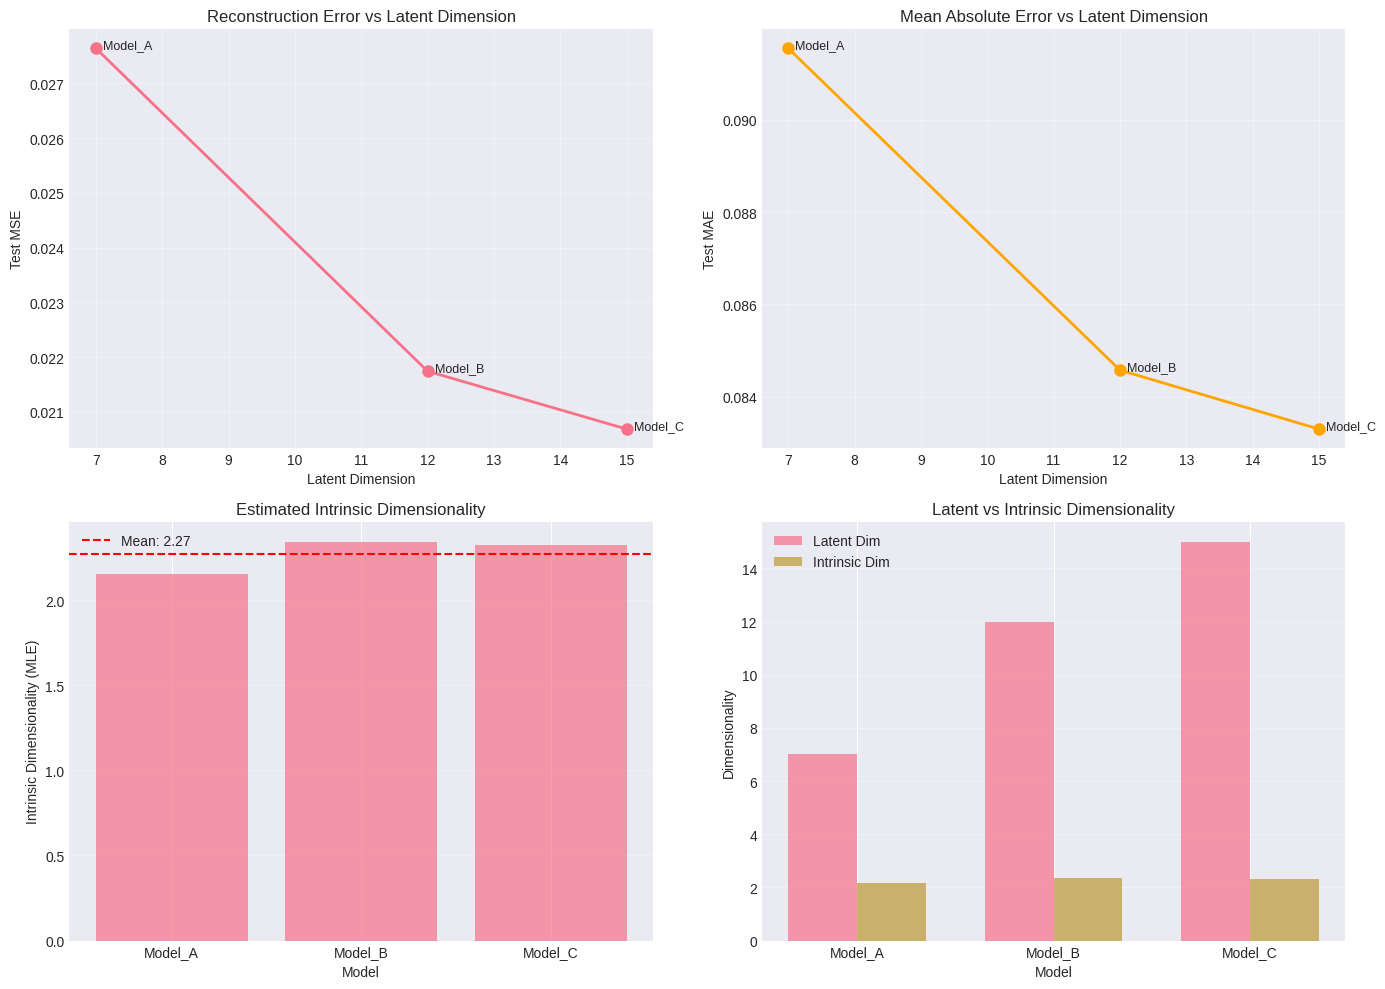

In [16]:
# Comparacion grafica de resultados
if 'experiment_results' in locals() and experiment_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Extraer datos
    models = []
    latent_dims = []
    test_mses = []
    test_maes = []
    d_intrinsics = []
    
    for exp_name, results in experiment_results.items():
        if results['status'] == 'completed':
            models.append(exp_name)
            latent_dims.append(results['latent_dim'])
            test_mses.append(results['test_mse'])
            test_maes.append(results['test_mae'])
            d_intrinsics.append(results['d_intrinsic_test'])
    
    # Plot 1: MSE vs Latent Dim
    axes[0,0].plot(latent_dims, test_mses, 'o-', linewidth=2, markersize=8)
    axes[0,0].set_xlabel('Latent Dimension')
    axes[0,0].set_ylabel('Test MSE')
    axes[0,0].set_title('Reconstruction Error vs Latent Dimension')
    axes[0,0].grid(True, alpha=0.3)
    for i, model in enumerate(models):
        axes[0,0].text(latent_dims[i], test_mses[i], f'  {model}', fontsize=9)
    
    # Plot 2: MAE vs Latent Dim
    axes[0,1].plot(latent_dims, test_maes, 'o-', linewidth=2, markersize=8, color='orange')
    axes[0,1].set_xlabel('Latent Dimension')
    axes[0,1].set_ylabel('Test MAE')
    axes[0,1].set_title('Mean Absolute Error vs Latent Dimension')
    axes[0,1].grid(True, alpha=0.3)
    for i, model in enumerate(models):
        axes[0,1].text(latent_dims[i], test_maes[i], f'  {model}', fontsize=9)
    
    # Plot 3: Intrinsic Dimensionality
    axes[1,0].bar(models, d_intrinsics, alpha=0.7)
    axes[1,0].axhline(y=np.mean(d_intrinsics), color='r', linestyle='--', 
                      label=f'Mean: {np.mean(d_intrinsics):.2f}')
    axes[1,0].set_xlabel('Model')
    axes[1,0].set_ylabel('Intrinsic Dimensionality (MLE)')
    axes[1,0].set_title('Estimated Intrinsic Dimensionality')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Comparison d_latent vs d_intrinsic
    x_pos = np.arange(len(models))
    width = 0.35
    axes[1,1].bar(x_pos - width/2, latent_dims, width, label='Latent Dim', alpha=0.7)
    axes[1,1].bar(x_pos + width/2, d_intrinsics, width, label='Intrinsic Dim', alpha=0.7)
    axes[1,1].set_xlabel('Model')
    axes[1,1].set_ylabel('Dimensionality')
    axes[1,1].set_title('Latent vs Intrinsic Dimensionality')
    axes[1,1].set_xticks(x_pos)
    axes[1,1].set_xticklabels(models)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Guardar
    fig_path = PLOTS_DIR / f'multi_model_comparison_{MODE}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\nGrafico guardado: {fig_path}")
    
    plt.show()
else:
    print("No hay resultados para graficar. Ejecuta el entrenamiento primero.")

---
## 7. Seleccion del Modelo Optimo

In [17]:
# Determinar modelo optimo basado en criterios
if 'experiment_results' in locals() and experiment_results:
    print("="*80)
    print("SELECCION DEL MODELO OPTIMO")
    print("="*80)
    
    completed_models = {k: v for k, v in experiment_results.items() if v['status'] == 'completed'}
    
    if completed_models:
        # Criterio 1: Menor MSE
        best_mse_model = min(completed_models.items(), key=lambda x: x[1]['test_mse'])
        
        # Criterio 2: d_intrinsic mas cercano a latent_dim
        def dimensionality_match(item):
            name, results = item
            return abs(results['d_intrinsic_test'] - results['latent_dim'])
        
        best_dim_model = min(completed_models.items(), key=dimensionality_match)
        
        print(f"\nCriterio 1 - Mejor MSE:")
        print(f"  Modelo: {best_mse_model[0]}")
        print(f"  MSE: {best_mse_model[1]['test_mse']:.6f}")
        print(f"  Latent dim: {best_mse_model[1]['latent_dim']}")
        
        print(f"\nCriterio 2 - Mejor match dimensionalidad:")
        print(f"  Modelo: {best_dim_model[0]}")
        print(f"  Latent dim: {best_dim_model[1]['latent_dim']}")
        print(f"  Intrinsic dim: {best_dim_model[1]['d_intrinsic_test']:.2f}")
        print(f"  Diferencia: {dimensionality_match(best_dim_model):.2f}")
        
        print(f"\n{'='*80}")
        print("RECOMENDACION:")
        print(f"{'='*80}")
        
        if best_mse_model[0] == best_dim_model[0]:
            print(f"\nModelo optimo claro: {best_mse_model[0]}")
            print("  - Mejor error de reconstruccion")
            print("  - Mejor ajuste de dimensionalidad")
        else:
            print(f"\nTradeoff entre modelos:")
            print(f"  - {best_mse_model[0]}: Mejor reconstruccion (MSE={best_mse_model[1]['test_mse']:.6f})")
            print(f"  - {best_dim_model[0]}: Mejor dimensionalidad (diff={dimensionality_match(best_dim_model):.2f})")
            print(f"\n  Sugerencia: Usar {best_dim_model[0]} para analisis de resiliencia")
            print("  (dimensionalidad intrinseca mas importante que MSE marginal)")
        
        print(f"\n{'='*80}")
    else:
        print("\nNo hay modelos completados para comparar")
else:
    print("No hay resultados disponibles para seleccion")

SELECCION DEL MODELO OPTIMO

Criterio 1 - Mejor MSE:
  Modelo: Model_C
  MSE: 0.020685
  Latent dim: 15

Criterio 2 - Mejor match dimensionalidad:
  Modelo: Model_A
  Latent dim: 7
  Intrinsic dim: 2.15
  Diferencia: 4.85

RECOMENDACION:

Tradeoff entre modelos:
  - Model_C: Mejor reconstruccion (MSE=0.020685)
  - Model_A: Mejor dimensionalidad (diff=4.85)

  Sugerencia: Usar Model_A para analisis de resiliencia
  (dimensionalidad intrinseca mas importante que MSE marginal)



---
## 8. Exportar para Notebook de Resiliencia

In [18]:
# Preparar datos para notebook 05_resilience.ipynb
if 'experiment_results' in locals() and experiment_results:
    print("="*80)
    print("EXPORTAR PARA ANALISIS DE RESILIENCIA")
    print("="*80)
    
    # Guardar configuracion para notebook 05
    resilience_config = {
        'mode': MODE,
        'scenarios': SCENARIOS,
        'experiments_completed': [k for k, v in experiment_results.items() if v['status'] == 'completed'],
        'recommended_model': best_dim_model[0] if 'best_dim_model' in locals() else None,
        'feature_names_file': str(TENSORS_DIR / f'feature_names_{MODE}.csv'),
        'metadata_file': str(TENSORS_DIR / f'metadata_{MODE}.pkl'),
        'results_file': str(results_file)
    }
    
    config_file = OUT_DIR / f'resilience_config_{MODE}.json'
    with open(config_file, 'w') as f:
        json.dump(resilience_config, f, indent=2)
    
    print(f"\nConfiguracion guardada: {config_file.name}")
    print(f"\nArchivos disponibles para notebook 05:")
    print(f"  1. Embeddings: {{model_name}}_embeddings_{MODE}.pkl")
    print(f"  2. Modelos: {{model_name}}_best_{MODE}.keras")
    print(f"  3. Resultados: multi_model_comparison_{MODE}.json")
    print(f"  4. Config: resilience_config_{MODE}.json")
    
    print(f"\n{'='*80}")
    print("SIGUIENTE PASO: Notebook 05_resilience.ipynb")
    print(f"{'='*80}")
    print("\nCargar modelo optimo y calcular:")
    print("  1. Indices de resiliencia por escenario")
    print("  2. Estabilidad de clusters en espacio latente")
    print("  3. Transiciones entre escenarios SSP")
    print("  4. Visualizaciones espaciales de resiliencia")
    print("="*80)
else:
    print("No hay resultados para exportar")


EXPORTAR PARA ANALISIS DE RESILIENCIA

Configuracion guardada: resilience_config_test.json

Archivos disponibles para notebook 05:
  1. Embeddings: {model_name}_embeddings_test.pkl
  2. Modelos: {model_name}_best_test.keras
  3. Resultados: multi_model_comparison_test.json
  4. Config: resilience_config_test.json

SIGUIENTE PASO: Notebook 05_resilience.ipynb

Cargar modelo optimo y calcular:
  1. Indices de resiliencia por escenario
  2. Estabilidad de clusters en espacio latente
  3. Transiciones entre escenarios SSP
  4. Visualizaciones espaciales de resiliencia


---
## Notas Finales

### Resultados Esperados

- Model_A (7D): Baseline con subcompresion conocida
- Model_B (12D): Dimension optima basada en analisis previo (d_intrinsic ~ 13-14)
- Model_C (15D): Exploracion de limite superior

### Metricas Clave

1. **MSE/MAE**: Calidad de reconstruccion
2. **d_intrinsic**: Complejidad real del espacio latente
3. **latent_dim vs d_intrinsic**: Ajuste de dimensionalidad

### Decisiones

- Si d_intrinsic < latent_dim: Modelo sobredimensionado (OK si diferencia pequena)
- Si d_intrinsic > latent_dim: Modelo subdimensionado (perder informacion)
- Optimo: d_intrinsic ≈ latent_dim (±1-2 dimensiones)

### Proximos Pasos

1. Ejecutar entrenamiento con RUN_TRAINING = True
2. Revisar resultados comparativos
3. Seleccionar modelo optimo
4. Continuar con notebook 05_resilience.ipynb